In [1]:
import pandas as pd              # For data handling (CSV, DataFrame)
import numpy as np               # For numerical operations
import matplotlib.pyplot as plt  # For data visualization

# Machine Learning libraries
from sklearn.model_selection import train_test_split  # To split data
from sklearn.preprocessing import StandardScaler      # For feature scaling
from sklearn.linear_model import LogisticRegression   # ML model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df = pd.read_csv(r"C:\Users\Varalakshmi\Desktop\newdisease\diabetes.csv")

In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.shape

(768, 9)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [7]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [8]:
columns_with_zero = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

# Replace zero values with column mean
for column in columns_with_zero:
    df[column] = df[column].replace(0, df[column].mean())

In [9]:
# Verify cleaning
df.describe()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.681605,72.254807,26.606479,118.660163,32.450805,0.471876,33.240885,0.348958
std,3.369578,30.436016,12.115932,9.631241,93.080358,6.875374,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,20.536458,79.799479,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,79.799479,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


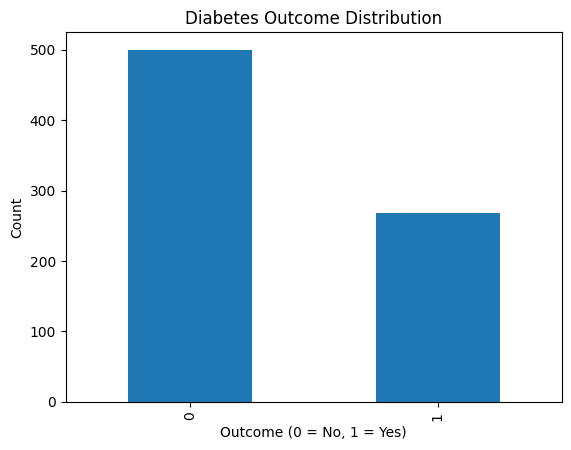

In [10]:
# ==============================
# 5. DATA VISUALIZATION
# ==============================

# Outcome distribution
df["Outcome"].value_counts().plot(kind="bar")
plt.title("Diabetes Outcome Distribution")
plt.xlabel("Outcome (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()


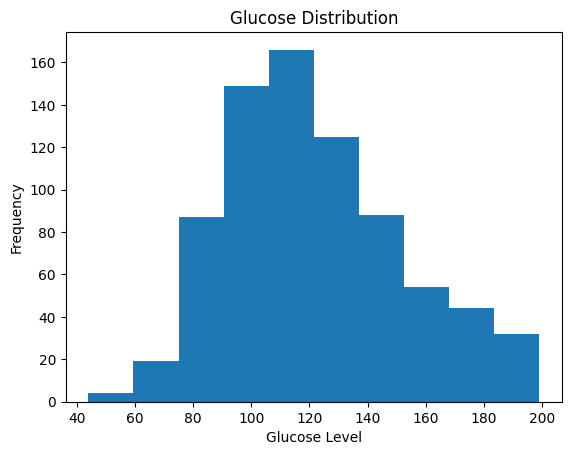

In [11]:
# Glucose distribution
plt.hist(df["Glucose"])
plt.title("Glucose Distribution")
plt.xlabel("Glucose Level")
plt.ylabel("Frequency")
plt.show()


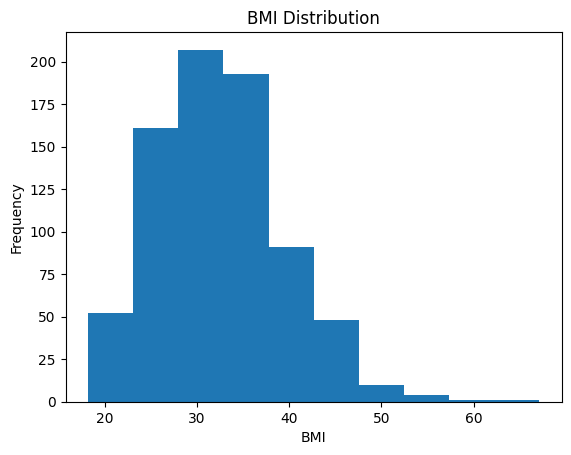

In [12]:
# BMI distribution
plt.hist(df["BMI"])
plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.show()


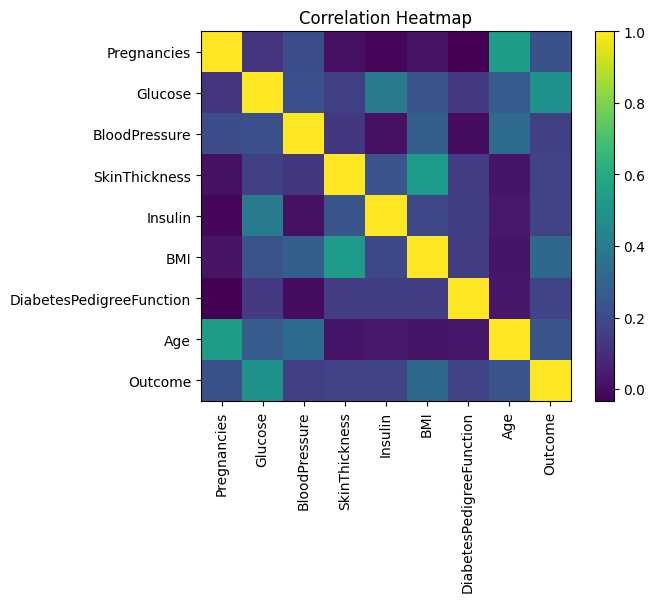

In [13]:


# Calculate correlation matrix
correlation = df.corr()

# Plot heatmap using matplotlib
plt.imshow(correlation)
plt.colorbar()
plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=90)
plt.yticks(range(len(correlation.columns)), correlation.columns)
plt.title("Correlation Heatmap")
plt.show()


In [14]:
# Separate features (X) and target (y)
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

In [16]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("Original:", y.value_counts())
print("After SMOTE:", y_resampled.value_counts())


Original: Outcome
0    500
1    268
Name: count, dtype: int64
After SMOTE: Outcome
1    500
0    500
Name: count, dtype: int64


In [17]:
import numpy as np

noise = np.random.normal(0, 0.01, X_resampled.shape)
X_augmented = X_resampled + noise


In [19]:
from sklearn.utils import resample
import pandas as pd

df_aug = pd.concat(
    [pd.DataFrame(X_augmented, columns=X.columns),
     pd.Series(y_resampled, name="Outcome")],
    axis=1
)

df_final = resample(
    df_aug,
    replace=True,
    n_samples=5000,
    random_state=42
)

X_final = df_final.drop("Outcome", axis=1)
y_final = df_final["Outcome"]

print("Final dataset size:", X_final.shape[0])
print(y_final.value_counts())


Final dataset size: 5000
Outcome
1    2543
0    2457
Name: count, dtype: int64


In [20]:
scaler = StandardScaler()       # Create scaler object
X_scaled = scaler.fit_transform(X)  # Scale features

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42
)

In [35]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb.fit(X_train, y_train)
y_pred = gb.predict(X_test)

from sklearn.metrics import accuracy_score
print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred))


Gradient Boosting Accuracy: 0.7467532467532467


In [37]:
y_probs = model.predict_proba(X_test)[:, 1]
y_pred = (y_probs >= 0.45).astype(int)

from sklearn.metrics import accuracy_score
print("Threshold adjusted accuracy:", accuracy_score(y_test, y_pred))


Threshold adjusted accuracy: 0.7467532467532467


In [36]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.83      0.77      0.80        99
           1       0.63      0.71      0.67        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154



In [23]:
y_pred = model.predict(X_test)

In [24]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7662337662337663


In [25]:
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       0.81      0.84      0.82        99
           1       0.69      0.64      0.66        55

    accuracy                           0.77       154
   macro avg       0.75      0.74      0.74       154
weighted avg       0.76      0.77      0.76       154



In [26]:
print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Confusion Matrix:

[[83 16]
 [20 35]]


In [27]:
import pickle   # Used to save and load ML models

# Open a file in write-binary mode
with open("diabetes_model.pkl", "wb") as file:
    pickle.dump(model, file)   # Save trained model

print("✅ Model saved successfully as diabetes_model.pkl")

✅ Model saved successfully as diabetes_model.pkl


In [28]:
with open("diabetes_scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

print("✅ Scaler saved successfully as scaler.pkl")

✅ Scaler saved successfully as scaler.pkl


In [29]:
import pickle

# Load saved model
model = pickle.load(open("diabetes_model.pkl", "rb"))

# Load scaler
scaler = pickle.load(open("diabetes_scaler.pkl", "rb"))

print("✅ Model and scaler loaded successfully")

✅ Model and scaler loaded successfully


In [30]:
# ==============================
# 16. SAMPLE PREDICTION
# ==============================

# Sample patient data
sample_data = [[2, 120, 70, 20, 85, 28.0, 0.5, 35]]

# Scale input
sample_data_scaled = scaler.transform(sample_data)

# Predict
prediction = model.predict(sample_data_scaled)

# Output result
if prediction[0] == 1:
    print("🩺 Diabetic")
else:
    print("🩺 Not Diabetic")


🩺 Not Diabetic


C:\Users\Varalakshmi\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [31]:
df_final.to_csv("diabetes_augmented_5000.csv", index=False)


In [32]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.7662337662337663
